In [ ]:

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/jiashenliu/515k-hotel-reviews-data-in-europe/Hotel_Reviews.csv


# Importing Libraires

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df = pd.read_csv('/kaggle/input/datasets/jiashenliu/515k-hotel-reviews-data-in-europe/Hotel_Reviews.csv')
df.head()


,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968


In [3]:
df.columns

Index(['Hotel_Address', 'Additional_Number_of_Scoring', 'Review_Date',
       'Average_Score', 'Hotel_Name', 'Reviewer_Nationality',
       'Negative_Review', 'Review_Total_Negative_Word_Counts',
       'Total_Number_of_Reviews', 'Positive_Review',
       'Review_Total_Positive_Word_Counts',
       'Total_Number_of_Reviews_Reviewer_Has_Given', 'Reviewer_Score', 'Tags',
       'days_since_review', 'lat', 'lng'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515738 entries, 0 to 515737
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   Hotel_Address                               515738 non-null  object 
 1   Additional_Number_of_Scoring                515738 non-null  int64  
 2   Review_Date                                 515738 non-null  object 
 3   Average_Score                               515738 non-null  float64
 4   Hotel_Name                                  515738 non-null  object 
 5   Reviewer_Nationality                        515738 non-null  object 
 6   Negative_Review                             515738 non-null  object 
 7   Review_Total_Negative_Word_Counts           515738 non-null  int64  
 8   Total_Number_of_Reviews                     515738 non-null  int64  
 9   Positive_Review                             515738 non-null  object 
 

In [9]:
df.isnull().sum()/df.shape[0]*100

Hotel_Address                                 0.000000
Additional_Number_of_Scoring                  0.000000
Review_Date                                   0.000000
Average_Score                                 0.000000
Hotel_Name                                    0.000000
Reviewer_Nationality                          0.000000
Negative_Review                               0.000000
Review_Total_Negative_Word_Counts             0.000000
Total_Number_of_Reviews                       0.000000
Positive_Review                               0.000000
Review_Total_Positive_Word_Counts             0.000000
Total_Number_of_Reviews_Reviewer_Has_Given    0.000000
Reviewer_Score                                0.000000
Tags                                          0.000000
days_since_review                             0.000000
lat                                           0.633655
lng                                           0.633655
dtype: float64

In [10]:
df.duplicated().sum()

np.int64(526)

In [3]:
clean_df = df.dropna(inplace=True)
clean_df = df.drop_duplicates()

In [4]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 511944 entries, 0 to 515737
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   Hotel_Address                               511944 non-null  object 
 1   Additional_Number_of_Scoring                511944 non-null  int64  
 2   Review_Date                                 511944 non-null  object 
 3   Average_Score                               511944 non-null  float64
 4   Hotel_Name                                  511944 non-null  object 
 5   Reviewer_Nationality                        511944 non-null  object 
 6   Negative_Review                             511944 non-null  object 
 7   Review_Total_Negative_Word_Counts           511944 non-null  int64  
 8   Total_Number_of_Reviews                     511944 non-null  int64  
 9   Positive_Review                             511944 non-null  object 
 10  R

In [13]:
df.describe()

,Additional_Number_of_Scoring,Average_Score,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,lat,lng
count,512470.000000,512470.000000,512470.000000,512470.000000,512470.000000,512470.000000,512470.000000,512470.000000,512470.000000
mean,500.118391,8.397934,18.541864,2747.504902,17.765052,7.152272,8.395594,49.442439,2.823803
std,501.419262,0.549133,29.693695,2322.698454,21.789025,11.028943,1.638170,3.466325,4.579425
min,1.000000,5.200000,0.000000,43.000000,0.000000,1.000000,2.500000,41.328376,-0.369758
25%,169.000000,8.100000,2.000000,1161.000000,5.000000,1.000000,7.500000,48.214662,-0.143372
50%,343.000000,8.400000,9.000000,2134.000000,11.000000,3.000000,8.800000,51.499981,0.010607
75%,666.000000,8.800000,23.000000,3633.000000,22.000000,8.000000,9.600000,51.516288,4.834443
max,2682.000000,9.800000,408.000000,16670.000000,395.000000,355.000000,10.000000,52.400181,16.429233


# Some EDA

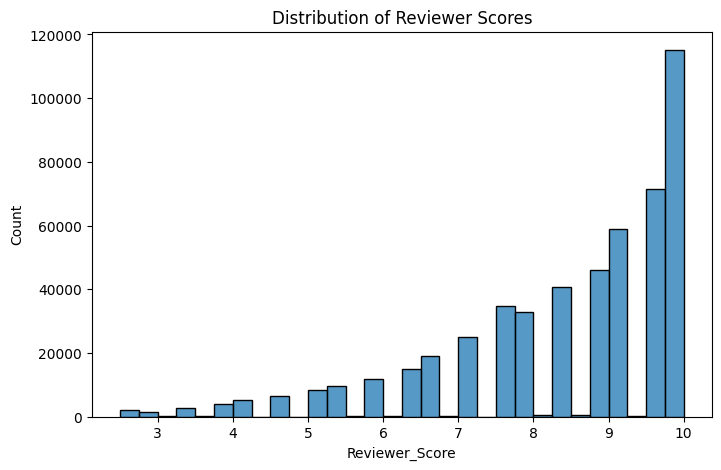

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(clean_df["Reviewer_Score"], bins=30)
plt.title("Distribution of Reviewer Scores")
plt.show()

In [15]:
# Top 10 Reviewer Nationality 
top_nationalities = clean_df["Reviewer_Nationality"].value_counts().head(10)

top_nationalities

Reviewer_Nationality
United Kingdom               244321
United States of America      35108
Australia                     21502
Ireland                       14733
United Arab Emirates          10170
Saudi Arabia                   8903
Netherlands                    8691
Switzerland                    8607
Germany                        7831
Canada                         7802
Name: count, dtype: int64

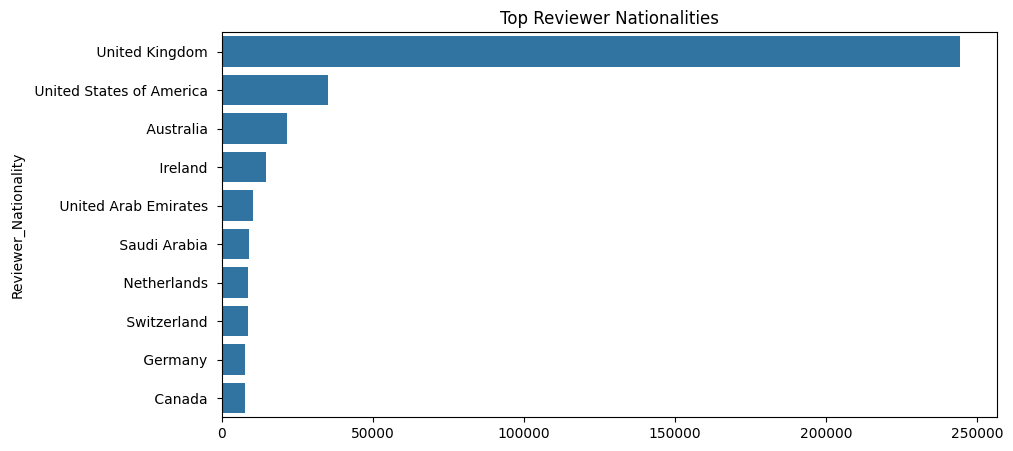

In [16]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_nationalities.values, y=top_nationalities.index)
plt.title("Top Reviewer Nationalities")
plt.show()

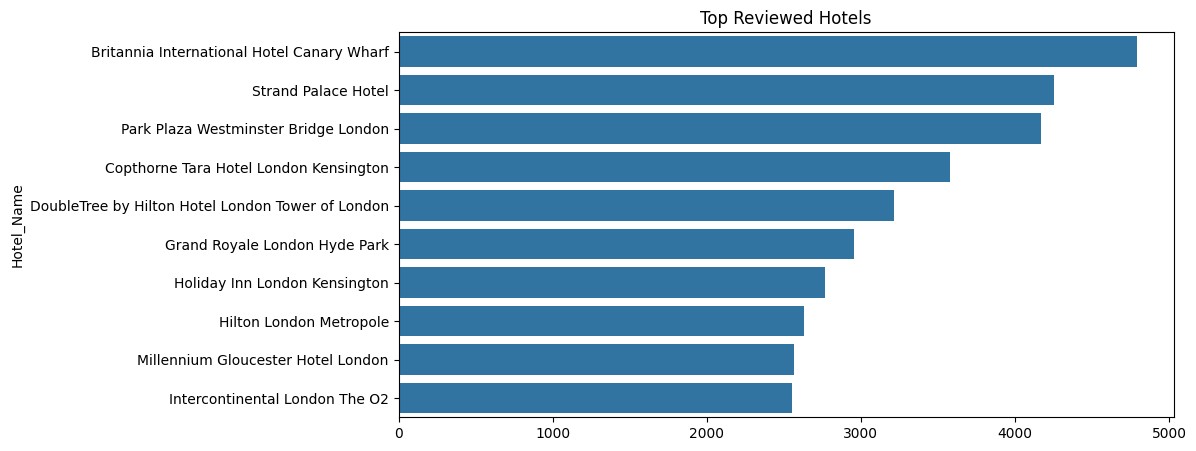

In [17]:
# Top 10 Hotels Name 
top_hotels = clean_df["Hotel_Name"].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_hotels.values, y=top_hotels.index)
plt.title("Top Reviewed Hotels")
plt.show()

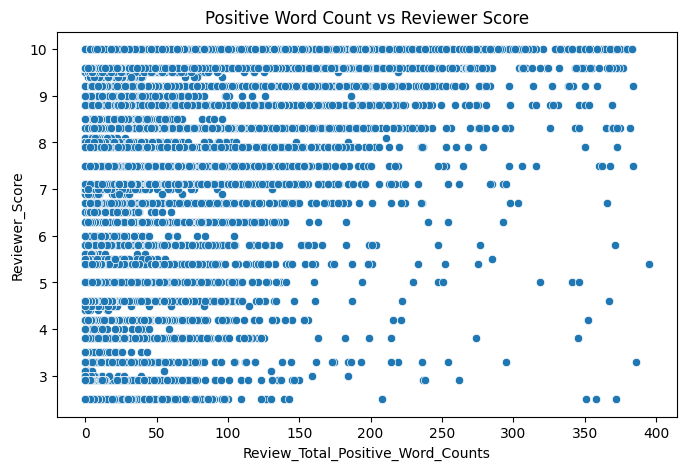

In [18]:
# Positive Words Count VS Reviewer Score
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="Review_Total_Positive_Word_Counts",
    y="Reviewer_Score",
    data=clean_df
)
plt.title("Positive Word Count vs Reviewer Score")
plt.show()

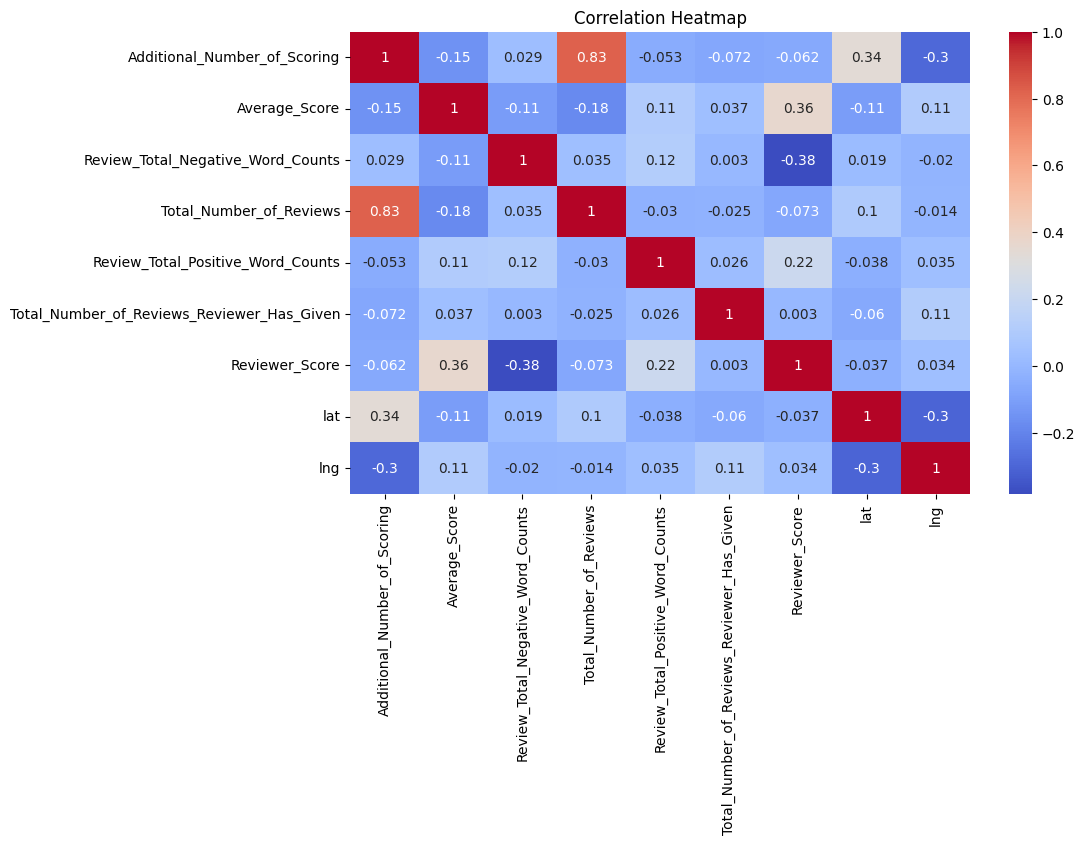

In [19]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# Sentiment Analysis 

## Data preparation

In [5]:
df_sen_ana = clean_df.copy()

In [6]:
df_sen_ana.head()

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968


In [7]:
df_sen_ana.columns

Index(['Hotel_Address', 'Additional_Number_of_Scoring', 'Review_Date',
       'Average_Score', 'Hotel_Name', 'Reviewer_Nationality',
       'Negative_Review', 'Review_Total_Negative_Word_Counts',
       'Total_Number_of_Reviews', 'Positive_Review',
       'Review_Total_Positive_Word_Counts',
       'Total_Number_of_Reviews_Reviewer_Has_Given', 'Reviewer_Score', 'Tags',
       'days_since_review', 'lat', 'lng'],
      dtype='object')

In [7]:
columns_to_drop = [
    "Hotel_Address",
    "Additional_Number_of_Scoring",
    "Review_Date",
    "Average_Score",
    "Hotel_Name",
    "Reviewer_Nationality",
    "Review_Total_Negative_Word_Counts",
    "Total_Number_of_Reviews",
    "Review_Total_Positive_Word_Counts",
    "Total_Number_of_Reviews_Reviewer_Has_Given",
    "Tags",
    "days_since_review",
    "lat",
    "lng"
]

df_sen_ana = df_sen_ana.drop(columns=columns_to_drop)

In [8]:
df_sen_ana.head()

,Negative_Review,Positive_Review,Reviewer_Score
0,I am so angry that i made this post available...,Only the park outside of the hotel was beauti...,2.9
1,No Negative,No real complaints the hotel was great great ...,7.5
2,Rooms are nice but for elderly a bit difficul...,Location was good and staff were ok It is cut...,7.1
3,My room was dirty and I was afraid to walk ba...,Great location in nice surroundings the bar a...,3.8
4,You When I booked with your company on line y...,Amazing location and building Romantic setting,6.7


In [9]:
df_sen_ana["Positive_Review"] = df_sen_ana["Positive_Review"].replace("No Positive","")
df_sen_ana["Negative_Review"] = df_sen_ana["Negative_Review"].replace("No Negative","")

df_sen_ana["review_text"] = df_sen_ana["Positive_Review"] + " " + df_sen_ana["Negative_Review"]

In [10]:
df_sen_ana.review_text[100]

' Location  Building work starting at 7am waking us up no mention of building work on booking com and on hotels web page it does say renovations but not that there would be noise disturbance Also air conditioning very very loud'

## Add Sentiment Label

In [11]:
def sentiment_label(score):
    if score >= 8.5:
        return 2   # Positive
    elif score >= 6:
        return 1   # Neutral
    else:
        return 0   # Negative

df_sen_ana["sentiment"] = df_sen_ana["Reviewer_Score"].apply(sentiment_label)

In [12]:
df_sen_ana.sample()

,Negative_Review,Positive_Review,Reviewer_Score,review_text,sentiment
288651,,Nice breakfast,9.6,Nice breakfast,2


<Axes: xlabel='sentiment', ylabel='count'>

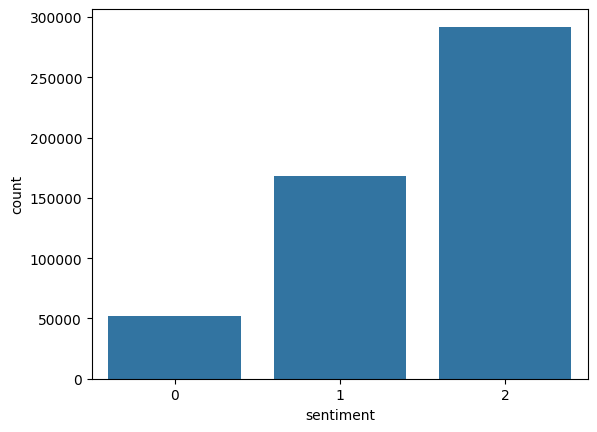

In [11]:
sns.countplot(x=df_sen_ana["sentiment"])

`Imbalanced sentiment`

## Text Cleaning

In [13]:
import re
import nltk
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

df_sen_ana["clean_review"] = df_sen_ana["review_text"].apply(clean_text)

In [14]:
df_sen_ana.clean_review[30]

'staff friendly helpful plus bar restaurant area beautiful located park old building simply stunning little bit pricey side'

In [15]:
# df_sen_ana.to_csv("hotel_reviews_clean.csv", index=False)

## Split Data

In [15]:
import pandas as pd
df_sen_ana = pd.read_csv('/kaggle/working/hotel_reviews_clean.csv')

In [16]:
from sklearn.model_selection import train_test_split

X = df_sen_ana["clean_review"]
y = df_sen_ana["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print (X_train.shape ,X_test.shape, y_train.shape, y_test.shape )

(409555,) (102389,) (409555,) (102389,)


In [17]:
X_train = X_train.fillna("")
X_test = X_test.fillna("")

## Modeling 

### ML 

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=5
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [20]:
# import pickle

# with open("tfidf_vectorizer.pkl", "wb") as f:
#     pickle.dump(vectorizer, f)

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score ,classification_report

model_lg = LogisticRegression(
     max_iter=1000,
    solver="liblinear",
    class_weight="balanced"
)

model_lg.fit(X_train_vec, y_train)

pred = model_lg.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.6833546572385706
              precision    recall  f1-score   support

           0       0.48      0.64      0.55     10365
           1       0.56      0.51      0.53     33558
           2       0.80      0.79      0.80     58466

    accuracy                           0.68    102389
   macro avg       0.61      0.65      0.62    102389
weighted avg       0.69      0.68      0.68    102389



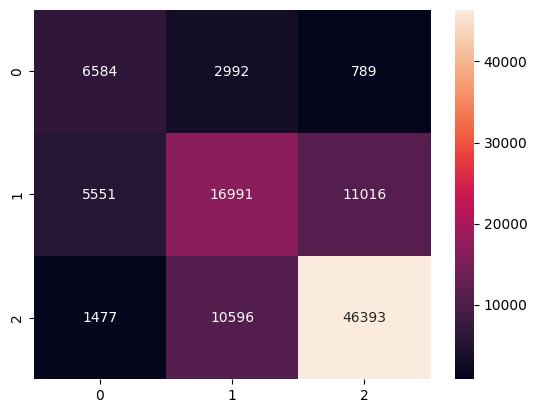

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [28]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

model_svm = LinearSVC(
    C=1.0,
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

model_svm.fit(X_train_vec, y_train)

y_pred_svm = model_svm.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.6758831515104161
              precision    recall  f1-score   support

           0       0.46      0.62      0.53     10365
           1       0.55      0.49      0.52     33558
           2       0.79      0.79      0.79     58466

    accuracy                           0.68    102389
   macro avg       0.60      0.63      0.61    102389
weighted avg       0.68      0.68      0.68    102389



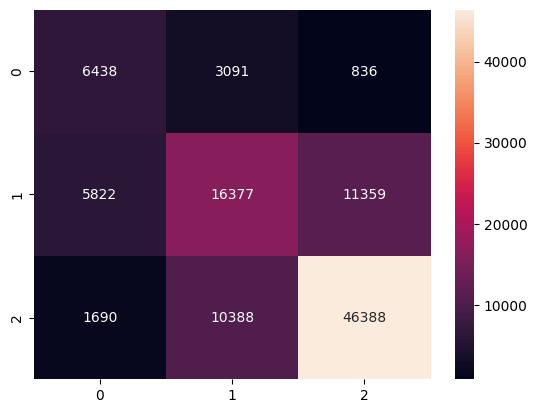

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

### ANN

In [21]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=300, random_state=42)

X_train_svd = svd.fit_transform(X_train_vec)
X_test_svd = svd.transform(X_test_vec)

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model_ann = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_svd.shape[1],)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(3, activation="softmax")
])

2026-03-14 22:38:20.176177: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773527900.590604      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773527900.698428      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773527901.697339      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773527901.697369      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773527901.697372      55 computation_placer.cc:177] computation placer alr

In [23]:
model_ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        19,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,443 (83.76 KB)

 Trainable params: 21,443 (83.76 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model_ann.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [25]:
history_ann = model_ann.fit(
    X_train_svd,
    y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    verbose=1,
)

Epoch 1/10


I0000 00:00:1773527940.836626     146 service.cc:152] XLA service 0x7e3368007010 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773527940.836664     146 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773527940.836670     146 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773527941.174001     146 cuda_dnn.cc:529] Loaded cuDNN version 91002


  70/1280 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5620 - loss: 0.9898

I0000 00:00:1773527942.811605     146 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1280/1280 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6388 - loss: 0.7657 - val_accuracy: 0.6874 - val_loss: 0.6672
Epoch 2/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6860 - loss: 0.6725 - val_accuracy: 0.6886 - val_loss: 0.6631
Epoch 3/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6897 - loss: 0.6633 - val_accuracy: 0.6914 - val_loss: 0.6597
Epoch 4/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6933 - loss: 0.6603 - val_accuracy: 0.6926 - val_loss: 0.6563
Epoch 5/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6938 - loss: 0.6567 - val_accuracy: 0.6942 - val_loss: 0.6551
Epoch 6/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6973 - loss: 0.6536 - val_accuracy: 0.6944 - val_loss: 0.6535
Epoch 7/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6968 - loss: 0.6523 - val_accuracy: 0.6953 - val_loss: 0.6541
Epoch 8/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6992 - loss: 0.6490 - val_accurac

In [26]:
loss, acc = model_ann.evaluate(X_test_svd, y_test)

print("Test Accuracy:", acc)

3200/3200 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.6959 - loss: 0.6516
Test Accuracy: 0.6969889402389526


In [27]:
import numpy as np

y_pred = model_ann.predict(X_test_svd)

y_pred_classes = np.argmax(y_pred, axis=1)

3200/3200 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.63      0.43      0.51     10365
           1       0.57      0.52      0.54     33558
           2       0.77      0.85      0.80     58466

    accuracy                           0.70    102389
   macro avg       0.65      0.60      0.62    102389
weighted avg       0.69      0.70      0.69    102389



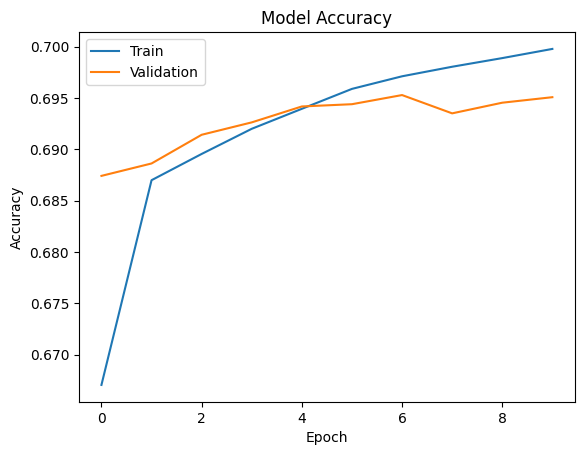

In [29]:
import matplotlib.pyplot as plt

plt.plot(history_ann.history["accuracy"])
plt.plot(history_ann.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

In [30]:
model_ann.save("ann_model.keras")

### RNN 

In [29]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


MAX_WORDS = 40000
MAX_LEN = 100  

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)


X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# padding
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post")

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout

EMBEDDING_DIM = 100

model_rnn = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    SimpleRNN(128, dropout=0.3, recurrent_dropout=0.2),
    Dense(64, activation="relu"),
    Dense(3, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [31]:
model_rnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [32]:
history_rnn = model_rnn.fit(
    X_train_pad,
    y_train,
    epochs=5,          
    batch_size=128,
    validation_split=0.2
)

Epoch 1/5
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 36s 12ms/step - accuracy: 0.5607 - loss: 0.9312 - val_accuracy: 0.5716 - val_loss: 0.9184
Epoch 2/5
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - accuracy: 0.5702 - loss: 0.9177 - val_accuracy: 0.5717 - val_loss: 0.9183
Epoch 3/5
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - accuracy: 0.5701 - loss: 0.9170 - val_accuracy: 0.5718 - val_loss: 0.9165
Epoch 4/5
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - accuracy: 0.5714 - loss: 0.9174 - val_accuracy: 0.5719 - val_loss: 0.9182
Epoch 5/5
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - accuracy: 0.5702 - loss: 0.9179 - val_accuracy: 0.5721 - val_loss: 0.9147


### LSTM


In [31]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 40000    
MAX_LEN = 100        

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post")

In [ ]:
import pickle

with open("tokenizer_best_lstm.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout

EMBEDDING_DIM = 128

model_lstm = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(3, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [33]:
model_lstm.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [34]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Early Stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Save Best Model
checkpoint = ModelCheckpoint(
    "best_lstm_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

# Train model
history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.6712 - loss: 0.7033
Epoch 1: val_loss improved from inf to 0.62542, saving model to best_lstm_model.keras
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 1112s 431ms/step - accuracy: 0.6712 - loss: 0.7033 - val_accuracy: 0.7075 - val_loss: 0.6254
Epoch 2/10
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.7191 - loss: 0.6087
Epoch 2: val_loss did not improve from 0.62542
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 1101s 430ms/step - accuracy: 0.7191 - loss: 0.6087 - val_accuracy: 0.7045 - val_loss: 0.6270
Epoch 3/10
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.7384 - loss: 0.5758
Epoch 3: val_loss did not improve from 0.62542
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 1102s 430ms/step - accuracy: 0.7384 - loss: 0.5758 - val_accuracy: 0.7083 - val_loss: 0.6304
Epoch 4/10
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.7516 - loss: 0.5508
Epoch 4: val_loss did not improve from 0.62542
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 1107s 432m

In [35]:
loss, acc = model_lstm.evaluate(X_test_pad, y_test)
print("LSTM Test Accuracy:", acc)

3200/3200 ━━━━━━━━━━━━━━━━━━━━ 260s 81ms/step - accuracy: 0.7097 - loss: 0.6274
LSTM Test Accuracy: 0.7100372314453125


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_pred = model_lstm.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes))

2028/3200 ━━━━━━━━━━━━━━━━━━━━ 1:32 79ms/step

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_lstm.history["accuracy"])
plt.plot(history_lstm.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()